<a href="https://colab.research.google.com/github/KhaiBow/EMSC2010-Week-9-Project/blob/main/EMSC2010_Group_Project_Week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project Week 9

## 1. Project Overview
Group name: Precipitation Pirates

Project week: 9

Project title: Modelling of Atmospheric CO₂ and Global Temperature Anomalies

Datasets used (name and source):

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Khai | Kedi | `Yes`/Partial/No| Add note|
| Data steward | Kedi | Binyao | `Yes`/Partial/No| Add note|
| Analysis / modelling | Binyao | Lee | `Yes`/Partial/No| Add note|
| Visualisation / interpretation | Lee | Juliet | `Yes`/Partial/No| Add note|
| Narrative | Juliet | Khai | `Yes`/Partial/No| Add note|
| Quality Control / Reproducibility  | Name | Name | Yes/Partial/No/`NA`| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

## Project Aim

This project investigates the relationship between atmospheric carbon dioxide (CO₂) concentrations and global temperature anomalies over time. The analysis combines statistical modelling with a simplified physical climate model to examine whether increasing CO₂ concentrations are associated with observed global warming trends.

Two complementary approaches are used:

1. A statistical approach using ordinary least squares (OLS) and Bayesian regression models.
2. A simplified physical Energy Balance Model (EBM) based on radiative forcing principles.

By comparing these approaches, the project evaluates both the predictive relationship between CO₂ and temperature and the extent to which simplified climate physics can reproduce observed warming trends.

## Data Preparation and Cleaning

Before analysis, the datasets required cleaning and standardisation to ensure consistency between variables. Missing values and placeholder values were removed, and both datasets were merged by year so that CO₂ and temperature observations could be directly compared across the same time periods.


In [1]:
import pandas as pd

# Load the datasets
# Make sure you uploaded these to Colab or they are in your GitHub path
df_co2 = pd.read_csv('co2_mm_mlo (1).csv', comment='#') # Skips NOAA metadata headers
df_temp = pd.read_csv('global_temp_anomalies_monthly.csv')

# Look at the first 5 rows to identify column names
print("CO2 Headers:", df_co2.columns.tolist())
print("Temp Headers:", df_temp.columns.tolist())

CO2 Headers: ['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
Temp Headers: ['Time', 'Anomaly (deg C)', 'Lower confidence limit (2.5%)', 'Upper confidence limit (97.5%)']


In [2]:
import numpy as np

# 1. Handle missing values (common in scientific data)
df_co2.replace([-99.99, -999.9], np.nan, inplace=True)
df_temp.replace([-99.99, -999.9], np.nan, inplace=True)

# Extract year from df_temp['Time']
df_temp['year'] = pd.to_datetime(df_temp['Time']).dt.year

# 2. Merge on 'year' column
# This creates a single table where both CO2 and Temp exist for the same year
merged_df = pd.merge(df_co2, df_temp, on='year')

# 3. Rename columns
# Select only needed columns and rename them
merged_df = merged_df[['year', 'average', 'Anomaly (deg C)']]
merged_df.columns = ['Year', 'CO2_ppm', 'Temp_Anomaly_C']

print("Cleaned data preview:")
print(merged_df.head())

Cleaned data preview:
   Year  CO2_ppm  Temp_Anomaly_C
0  1958   315.71        0.257871
1  1958   315.71        0.091331
2  1958   315.71        0.006063
3  1958   315.71       -0.067988
4  1958   315.71        0.016500


In [3]:
!pip install bambi pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 11.6 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import bambi as bmb
import arviz as az

In [5]:
# Use the merged dataset prepared by the Data Steward
# Take annual mean since merged_df contains monthly data
df = merged_df.groupby('Year')[['CO2_ppm', 'Temp_Anomaly_C']].mean()
df.columns = ['co2', 'temp']  # rename for consistency
df = df.dropna()

## Physical Climate Modelling

This project applies a simplified Energy Balance Model (EBM). The EBM is based on physical climate principles, including incoming solar radiation, Earth’s albedo, and greenhouse gas effects.

The model estimates how changes in atmospheric CO₂ alter Earth’s radiative balance and surface temperature. While simplified, the EBM provides an interpretable framework for comparing theoretical warming predictions against observed climate data.

In [6]:
# Physical constants for the zero-dimensional Energy Balance Model (EBM)
S0    = 1361.0   # solar constant (W/m²) — energy received from the Sun
sigma = 5.67e-8  # Stefan-Boltzmann constant (W/m²/K⁴)
alpha = 0.30     # Earth's albedo — fraction of sunlight reflected back to space
eps0  = 0.78     # baseline atmospheric emissivity (greenhouse strength)
lam   = 0.06     # emissivity sensitivity to CO₂ doubling
                 # tuned so that doubling CO₂ produces ~3°C warming (IPCC estimate)

# Use the first CO₂ observation as our reference point
CO2_ref = df['co2'].iloc[0]

# Calculate reference surface temperature from the EBM at baseline emissivity
# Factor of 1/4 converts solar disk flux to sphere-averaged flux
T_ref = (S0*(1-alpha)/4 / (sigma*(1 - eps0/2))) ** 0.25

def ebm_temp_anomaly(co2_ppm):
    # CO₂ increases emissivity logarithmically, like radiative forcing
    eps = eps0 + lam * np.log2(co2_ppm / CO2_ref)
    # Calculate new equilibrium surface temperature with updated emissivity
    T   = (S0*(1-alpha)/4 / (sigma*(1 - eps/2))) ** 0.25
    # Return the anomaly relative to the reference temperature
    return T - T_ref

# Apply EBM prediction to every year in our dataset
df['ebm_pred'] = df['co2'].apply(ebm_temp_anomaly)
print(f"Reference temperature: {T_ref:.2f} K ({T_ref-273.15:.2f} °C)")
print(f"EBM predicted warming 1958→present: {df['ebm_pred'].iloc[-1]:.2f} °C")


Reference temperature: 288.07 K (14.92 °C)
EBM predicted warming 1958→present: 1.61 °C


## Linear Regression Analysis

A linear regression model was first used as a statistical baseline to evaluate the relationship between atmospheric CO₂ concentration and global temperature anomaly.

The regression tests whether increases in CO₂ are associated with increases in temperature anomaly and quantifies the strength of this relationship using the coefficient of determination (R²).

Slope    : 0.0108 °C/ppm
Intercept: -3.5792 °C
R²       : 0.9335
p-value  : 3.73e-41


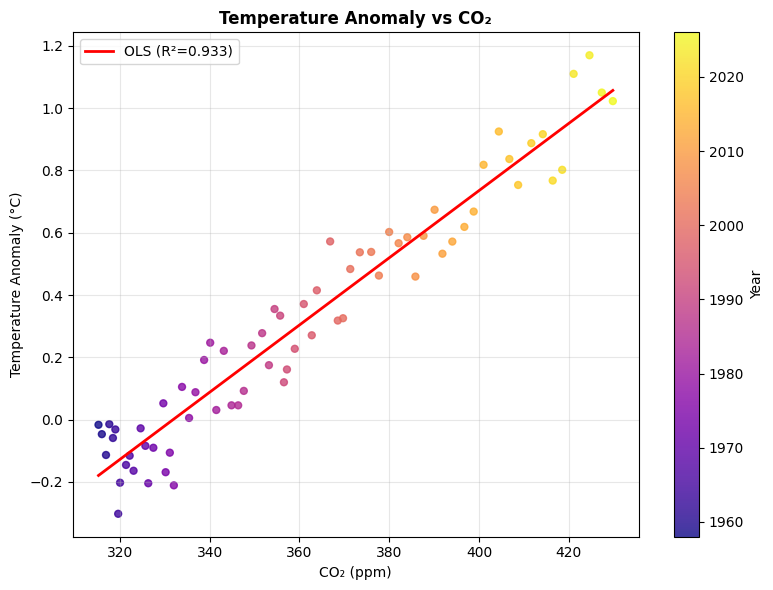

In [7]:
# Fit a simple OLS linear regression as a statistical baseline
# This tests whether CO₂ concentration can linearly predict temperature anomaly
reg = linregress(df['co2'], df['temp'])
print(f"Slope    : {reg.slope:.4f} °C/ppm")   # warming per 1 ppm increase in CO₂
print(f"Intercept: {reg.intercept:.4f} °C")
print(f"R²       : {reg.rvalue**2:.4f}")       # proportion of variance explained
print(f"p-value  : {reg.pvalue:.2e}")          # statistical significance

fig, ax = plt.subplots(figsize=(8, 6))
# Colour each point by year to show temporal progression
sc = ax.scatter(df['co2'], df['temp'], c=df.index, cmap='plasma', s=25, alpha=0.8)
x_line = np.linspace(df['co2'].min(), df['co2'].max(), 200)
ax.plot(x_line, reg.intercept + reg.slope * x_line,
        color='red', lw=2, label=f'OLS (R²={reg.rvalue**2:.3f})')
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('CO₂ (ppm)'); ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Temperature Anomaly vs CO₂', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Interpretation of Linear Regression Results

The regression analysis produced a strong positive relationship between atmospheric CO₂ concentration and global temperature anomaly, with an R² value of approximately 0.93. This indicates that a large proportion of the observed temperature variability is correlated by changes in CO₂ concentration.

The very small p-value suggests that this relationship is statistically significant and unlikely to occur due to random chance. Overall, the results support the hypothesis that increasing atmospheric CO₂ is strongly associated with global warming.

## Bayesian Polynomial Regression

While linear regression provides a useful baseline, climate relationships may not be perfectly linear. To investigate potential nonlinear behaviour, Bayesian polynomial regression models were fitted.

Bayesian methods were chosen because they allow uncertainty to be incorporated directly into the model and provide probabilistic estimates rather than single best-fit values.

Four models were tested:
- Linear
- Quadratic
- Cubic
- Quartic

In [8]:
# Prepare the data for Bayesian modelling
data = df.copy().reset_index()
data.columns = ['year', 'co2', 'temp', 'ebm_pred']

# Scale CO₂ to have mean=0 and std=1
# This is important for numerical stability in Bayesian models
data['x_scaled']  = (data['co2'] - data['co2'].mean()) / data['co2'].std()
data['x2_scaled'] = data['x_scaled'] ** 2   # used for quadratic regression
data['x3_scaled'] = data['x_scaled'] ** 3   # used for cubic regression
data['x4_scaled'] = data['x_scaled'] ** 4   # used for quartic regression
data['y'] = data['temp']                     # response variable: temperature anomaly

# Fit four polynomial models using bambi (simple-to-complex strategy)
# log_likelihood=True is required for LOO-CV model comparison

# Linear model (first-order polynomial)
model_linear = bmb.Model('y ~ x_scaled', data)
idata_linear = model_linear.fit(idata_kwargs={'log_likelihood': True})

# Quadratic model (second-order polynomial)
model_quad = bmb.Model('y ~ x_scaled + x2_scaled', data)
idata_quad = model_quad.fit(idata_kwargs={'log_likelihood': True})

# Cubic model (third-order polynomial)
model_cubic = bmb.Model('y ~ x_scaled + x2_scaled + x3_scaled', data)
idata_cubic = model_cubic.fit(idata_kwargs={'log_likelihood': True})

# Quartic model (fourth-order polynomial)
model_quart = bmb.Model('y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled', data)
idata_quart = model_quart.fit(idata_kwargs={'log_likelihood': True})


Output()

Output()

Output()

Output()

           rank   elpd_loo     p_loo  elpd_diff        weight        se  \
linear        0  60.189498  2.548202   0.000000  7.772661e-01  4.237389   
quadratic     1  59.454534  3.503698   0.734965  0.000000e+00  4.319512   
quartic       2  58.882872  5.772312   1.306626  2.227339e-01  4.319875   
cubic         3  58.449122  4.465041   1.740376  7.216450e-15  4.337794   

                dse  warning scale  
linear     0.000000    False   log  
quadratic  0.767286    False   log  
quartic    2.201270    False   log  
cubic      0.964780    False   log  


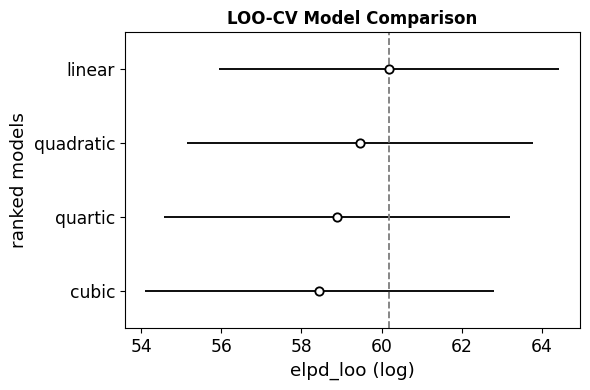

In [9]:
# Compare all four models using Leave-One-Out Cross-Validation (LOO-CV)
# Higher ELPD (expected log pointwise predictive density) = better model
comparison = az.compare({
    'linear'   : idata_linear,
    'quadratic': idata_quad,
    'cubic'    : idata_cubic,
    'quartic'  : idata_quart
})
print(comparison)  # models ranked from best to worst

# Plot the comparison — the best model has the highest ELPD
az.plot_compare(comparison, insample_dev=False)
plt.title('LOO-CV Model Comparison', fontweight='bold')
plt.tight_layout(); plt.show()


### Interpretation of Model Comparison

The model comparison indicates that the linear Bayesian model achieved the highest predictive performance according to the LOO-CV metric. Although more complex polynomial models were tested, they did not substantially improve predictive accuracy.

This suggests that the relationship between atmospheric CO₂ concentration and global temperature anomaly is largely linear over the observed period.

/usr/local/lib/python3.12/dist-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


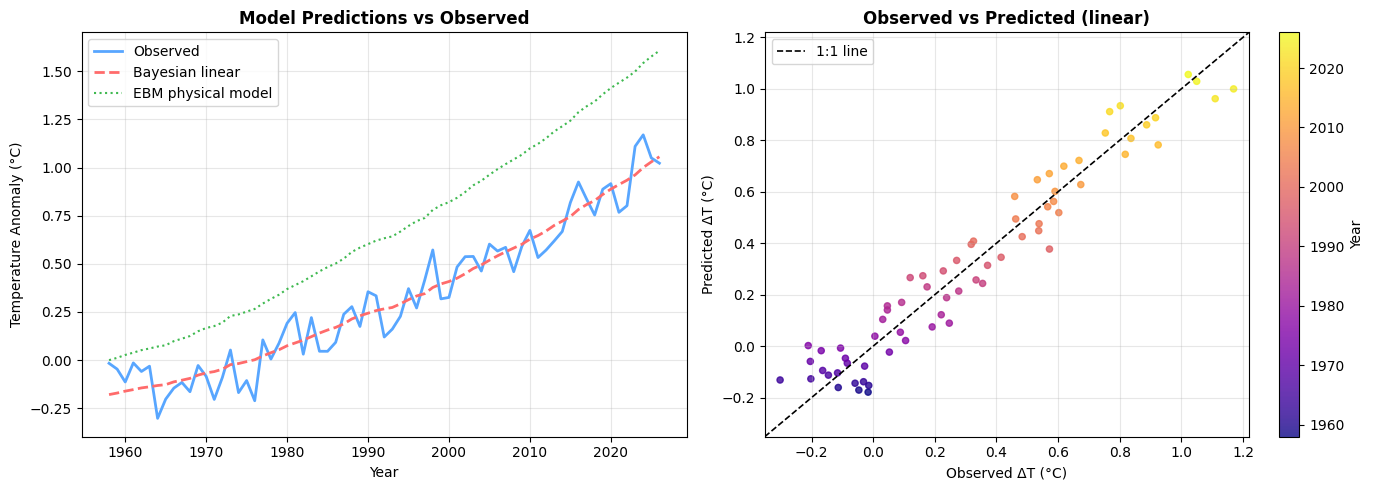

In [10]:
# Automatically select the best model based on LOO-CV ranking
best_model_name = comparison.index[0]
best_idata = {'linear': idata_linear, 'quadratic': idata_quad,
              'cubic': idata_cubic, 'quartic': idata_quart}[best_model_name]
best_model = {'linear': model_linear, 'quadratic': model_quad,
              'cubic': model_cubic, 'quartic': model_quart}[best_model_name]

# Generate posterior mean predictions for each data point
best_model.predict(best_idata, kind='mean')
pred_mean = best_idata.posterior['mu'].mean(dim=['chain', 'draw']).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Time series comparison of observed, Bayesian model, and EBM
ax = axes[0]
ax.plot(data['year'], data['y'], color='#58a6ff', lw=2, label='Observed')
ax.plot(data['year'], pred_mean, color='#ff6b6b', lw=2, ls='--',label=f'Bayesian {best_model_name}')
ax.plot(data['year'], data['ebm_pred'], color='#3fb950', lw=1.5, ls=':',label='EBM physical model')
ax.set_xlabel('Year'); ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Model Predictions vs Observed', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel 2: Scatter plot of observed vs predicted values
# Points should fall close to the 1:1 line if the model fits well
ax = axes[1]
sc = ax.scatter(data['y'], pred_mean, c=data['year'], cmap='plasma', s=20, alpha=0.8)
lims = [min(data['y'].min(), pred_mean.min())-0.05,
        max(data['y'].max(), pred_mean.max())+0.05]
ax.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')  # perfect prediction line
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Observed ΔT (°C)'); ax.set_ylabel('Predicted ΔT (°C)')
ax.set_title(f'Observed vs Predicted ({best_model_name})', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Year')
plt.tight_layout(); plt.show()

### Additional Visualizations: Residuals and Time Series

## Residual Analysis

Residual analysis was used to assess model performance and identify systematic prediction errors. Residuals represent the difference between observed and predicted temperature anomalies.

If residuals are randomly distributed around zero, this suggests that the model adequately captures the underlying trend. Systematic patterns or clustering may indicate missing processes, nonlinear behaviour, or model limitations.

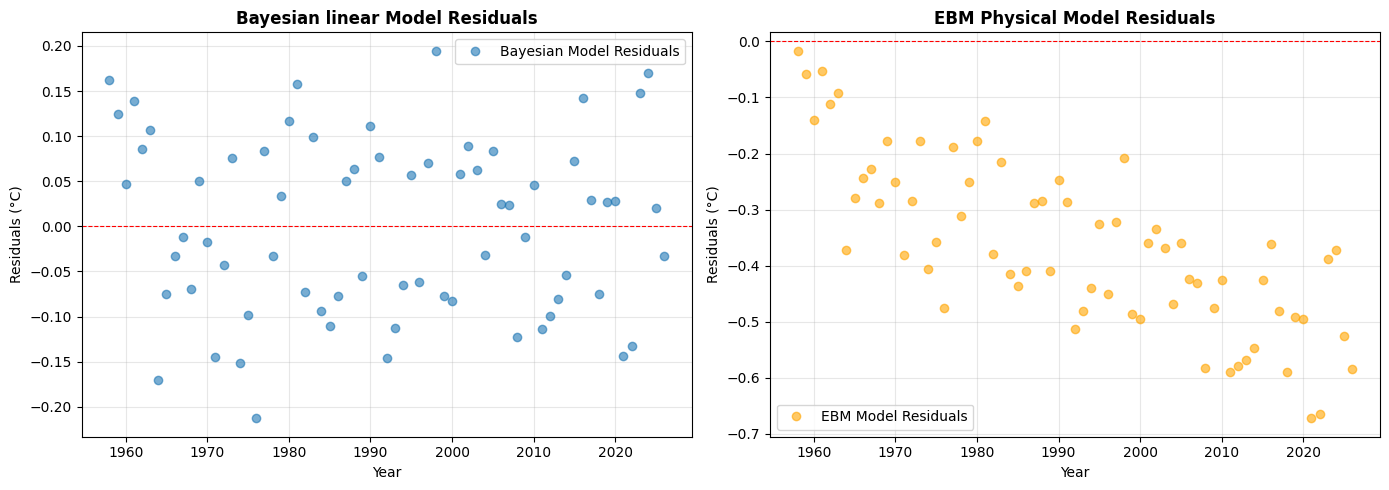

In [11]:
# Calculate residuals for the best Bayesian model and the EBM
data['bayesian_residuals'] = data['y'] - pred_mean
data['ebm_residuals'] = data['y'] - data['ebm_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Bayesian Model Residuals over Time
ax = axes[0]
ax.plot(data['year'], data['bayesian_residuals'], marker='o', linestyle='', alpha=0.6, label='Bayesian Model Residuals')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Residuals (°C)')
ax.set_title(f'Bayesian {best_model_name} Model Residuals', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Panel 2: EBM Model Residuals over Time
ax = axes[1]
ax.plot(data['year'], data['ebm_residuals'], marker='o', linestyle='', alpha=0.6, color='orange', label='EBM Model Residuals')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Residuals (°C)')
ax.set_title('EBM Physical Model Residuals', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

These residual plots help us see if there are any systematic errors in the models over time. Ideally, residuals should be randomly scattered around zero.

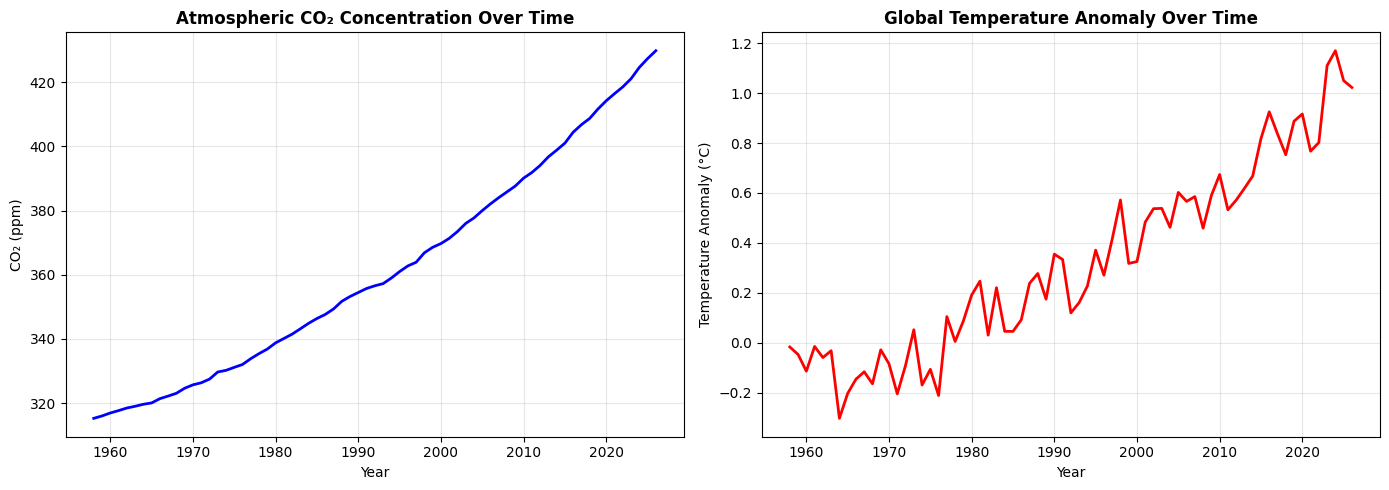

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: CO2 Concentration over Time
ax = axes[0]
ax.plot(data['year'], data['co2'], color='blue', lw=2)
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Atmospheric CO₂ Concentration Over Time', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: Global Temperature Anomaly over Time
ax = axes[1]
ax.plot(data['year'], data['temp'], color='red', lw=2)
ax.set_xlabel('Year'); ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Temperature Anomaly Over Time', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


1.  co2 Concentration: Displays the trend of atmospheric co2 concentration over the years.
2.  Global Temperature Anomaly: Shows the trend of global temperature anomaly over the same period.
These visualisations allow for a clear inspection of the individual longterm trends and changes in both co2 and temperature, showing their parallel increase.

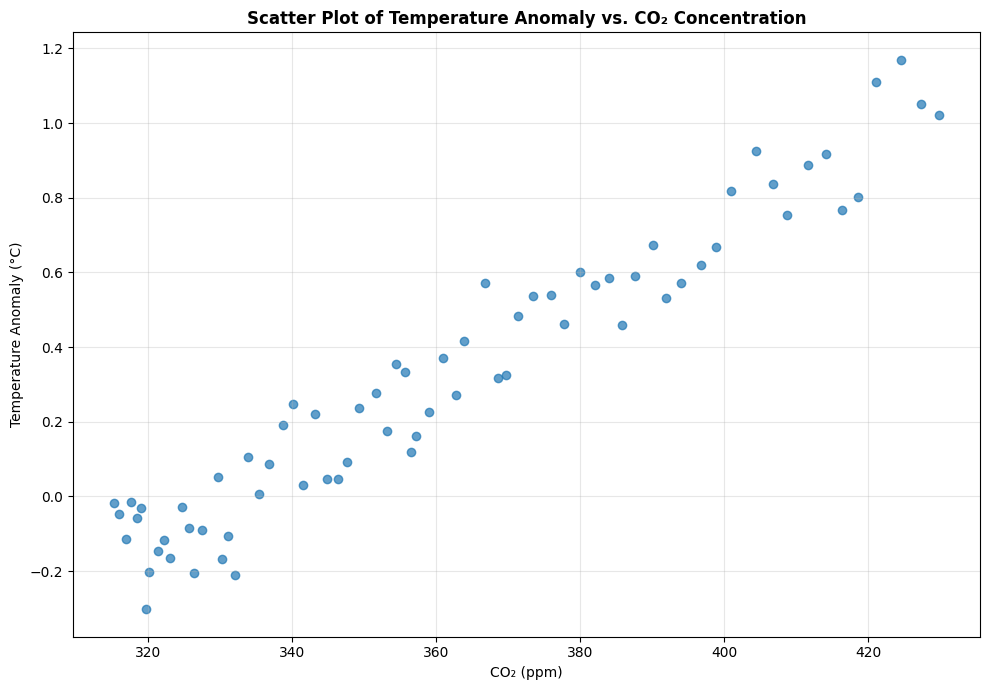

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(data['co2'], data['temp'], alpha=0.7)
ax.set_xlabel('CO₂ (ppm)')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Scatter Plot of Temperature Anomaly vs. CO₂ Concentration', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

These plots show the individual trends of co2 concentration and global temperature anomaly over the years covered by the dataset, highlighting the increasing trends in both.

## Limitations

Several limitations should be considered when interpreting these results.

1. The Energy Balance Model used in this project is highly simplified and does not include important climate processes such as ocean circulation, aerosols, cloud feedbacks, volcanic activity, or regional climate variability.

2. Correlation does not necessarily imply direct causation. Although strong relationships between CO₂ and temperature are observed, climate systems are influenced by multiple interacting variables.

3. The analysis relies on historical observational datasets, which may contain measurement uncertainties and methodological assumptions.


## Conclusion

This project demonstrates a strong relationship between atmospheric CO₂ concentration and global temperature anomalies over time.

Both statistical and physical modelling approaches reproduced the long-term warming trend observed in the climate record. Linear regression and Bayesian analysis showed that increasing CO₂ concentrations strongly correlate with rising temperatures, while the Energy Balance Model provided a physically grounded explanation for this warming.

Model comparison suggested that relatively simple models were sufficient to capture the dominant relationship between CO₂ and temperature, indicating that the warming trend over the analysed period is broadly linear.

Overall, the results support the understanding that rising atmospheric CO₂ concentrations are a driver of global warming.

# Reflections
1. Khai: This week my role was the Github and integration. This week was a bit of a step back from the nitty-gritty data analysis and more hands on with the Github side of things. I had to refer back to parts of assignment 1 to refamiliarise myself with the ins and outs of Github. Having a great team made my job real easy this week :)

2. Kedi: This week, I served as the Data Steward for our climate model project. My main job was finding and cleaning the CO2 and temperature datasets from NOAA and NASA. I had to fix several "Key Error" issues in Python because the file headers were messy. I also merged the monthly data into yearly averages to make it easier for my team to use. It was a good lesson in why data organization matters before starting any modeling work.

3. Binyao: I was responsible for building the Energy Balance Model and running the Bayesian polynomial regression analysis. One challenge I faced was linking the physical model to the statistical analysis, but I learned how the EBM provides the theoretical basis for the CO₂-temperature relationship that the Bayesian models then quantify. I also learned the importance of producing clean output data for the Visualisation team to use directly.

4. Lee:  I created some visualisations such as the time series plots of co2 concentrations and temperature anomalies, scatter plots illustrating their relationship, and residual plots  to evaluate model performance. One challenge I encountered was deciding which visualisations were the most effective and whether adding additional graphs would provide further insight or just become redundant. I learned how that selecting the right visualisations that communicate the key findings clearly, support the overall analysis, rather than distracting from the main conclusions.

5. Juliet:
I was more difficult than expected to come in and try and decipher the flow and purpose of all the code. I tried to create headings to seperate sections and try to explain the purpose of each part of the analysis. In addition, I also added some interpretations as well as a limitations and conclusion section to try to create a more finished project narrative.